Total data points: 1959
Time range: 0.000 ms to 95.000 ms

Last 40ms data points: 466
Time range: 55.032 ms to 95.000 ms


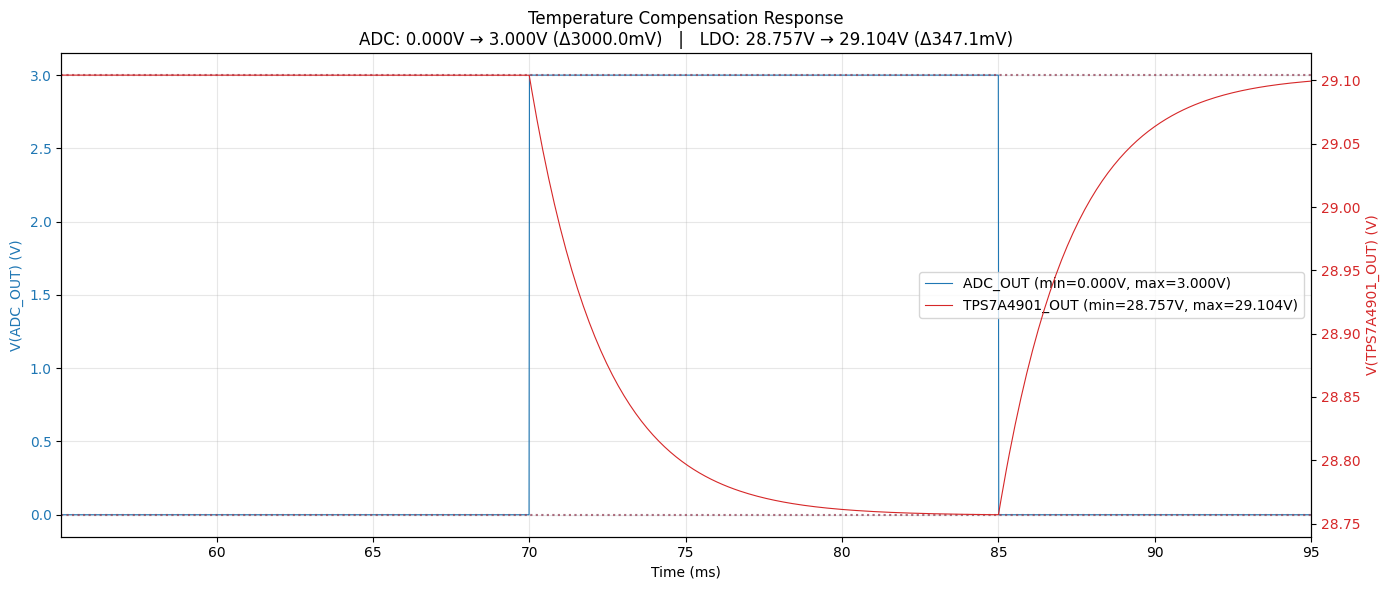


STATISTICAL ANALYSIS - Last 40ms

V(ADC_OUT):
  Minimum:    0.000000 V
  Maximum:    3.000000 V
  Range:      3000.0000 mV

V(TPS7A4901_OUT):
  Minimum:    28.757032 V
  Maximum:    29.104155 V
  Range:      347.1222 mV

Transfer Characteristics:
  Gain:       -78.0475 mV/V
  Offset:     29.0602 V
  R²:         0.577652

Temperature Compensation:
  Temperature range:     20°C to 35°C (Δ15°C)
  LDO adjustment:        347.12 mV
  Compensation rate:     23.14 mV/°C
  SiPM Vbr temp coeff:   21.5 mV/°C (from datasheet)
  Match accuracy:        107.6%


In [27]:
import ltspice
import matplotlib.pyplot as plt
import numpy as np

raw = ltspice.Ltspice('/workspace/Simulation/LTspice/Schematics/TemperatureAdjustmentSensorBias.raw')
raw.parse()

# Output directory
output_dir = '/workspace/Simulation/JupyterLab/Outputs/'

# Extract data
time = raw.get_time() * 1000  # Convert to ms
v_ldo = raw.get_data('V(LDO_OUT)')
v_adc = raw.get_data('V(ADC_OUT)')

print(f"Total data points: {len(time)}")
print(f"Time range: {time[0]:.3f} ms to {time[-1]:.3f} ms")

# ============================================
# Extract last 40ms of data
# ============================================
analysis_window = 40  # ms
last_mask = time >= (time.max() - analysis_window)
time_last = time[last_mask]
v_ldo_last = v_ldo[last_mask]
v_adc_last = v_adc[last_mask]

print(f"\nLast {analysis_window}ms data points: {len(time_last)}")
print(f"Time range: {time_last.min():.3f} ms to {time_last.max():.3f} ms")

# Calculate statistics
v_adc_min, v_adc_max = np.min(v_adc_last), np.max(v_adc_last)
v_ldo_min, v_ldo_max = np.min(v_ldo_last), np.max(v_ldo_last)
v_adc_range = v_adc_max - v_adc_min
v_ldo_range = v_ldo_max - v_ldo_min

# Linear fit
coeffs = np.polyfit(v_adc_last, v_ldo_last, 1)

# ============================================
# PLOT 1: Time Domain - Dual Y-Axis (Combined)
# ============================================
fig1, ax1 = plt.subplots(figsize=(14, 6))

# ADC on left axis
color_adc = 'tab:blue'
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('V(ADC_OUT) (V)', color=color_adc)
line1, = ax1.plot(time_last, v_adc_last, color=color_adc, linewidth=0.8, label='ADC_OUT')
ax1.tick_params(axis='y', labelcolor=color_adc)
ax1.set_xlim(time_last.min(), time_last.max())

# Add min/max annotations for ADC
ax1.axhline(y=v_adc_min, color=color_adc, linestyle=':', alpha=0.5)
ax1.axhline(y=v_adc_max, color=color_adc, linestyle=':', alpha=0.5)

# LDO on right axis
ax2 = ax1.twinx()
color_ldo = 'tab:red'
ax2.set_ylabel('V(TPS7A4901_OUT) (V)', color=color_ldo)
line2, = ax2.plot(time_last, v_ldo_last, color=color_ldo, linewidth=0.8, label='LDO_OUT')
ax2.tick_params(axis='y', labelcolor=color_ldo)

# Add min/max annotations for LDO
ax2.axhline(y=v_ldo_min, color=color_ldo, linestyle=':', alpha=0.5)
ax2.axhline(y=v_ldo_max, color=color_ldo, linestyle=':', alpha=0.5)

# Title with key values
ax1.set_title(f'Temperature Compensation Response\n'
              f'ADC: {v_adc_min:.3f}V → {v_adc_max:.3f}V (Δ{v_adc_range*1000:.1f}mV)   |   '
              f'LDO: {v_ldo_min:.3f}V → {v_ldo_max:.3f}V (Δ{v_ldo_range*1000:.1f}mV)')

# Combined legend
lines = [line1, line2]
labels = [f'ADC_OUT (min={v_adc_min:.3f}V, max={v_adc_max:.3f}V)',
          f'TPS7A4901_OUT (min={v_ldo_min:.3f}V, max={v_ldo_max:.3f}V)']
ax1.legend(lines, labels, loc='center right')

ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir + 'TemperatureAdjustmentTimeDomain.png', dpi=300)
plt.show()


# ============================================
# STATISTICAL ANALYSIS
# ============================================
print("\n" + "=" * 60)
print(f"STATISTICAL ANALYSIS - Last {analysis_window}ms")
print("=" * 60)

print(f"\nV(ADC_OUT):")
print(f"  Minimum:    {v_adc_min:.6f} V")
print(f"  Maximum:    {v_adc_max:.6f} V")
print(f"  Range:      {v_adc_range*1000:.4f} mV")

print(f"\nV(TPS7A4901_OUT):")
print(f"  Minimum:    {v_ldo_min:.6f} V")
print(f"  Maximum:    {v_ldo_max:.6f} V")
print(f"  Range:      {v_ldo_range*1000:.4f} mV")

print(f"\nTransfer Characteristics:")
print(f"  Gain:       {coeffs[0]*1000:.4f} mV/V")
print(f"  Offset:     {coeffs[1]:.4f} V")

# R-squared
ss_res = np.sum((v_ldo_last - np.polyval(coeffs, v_adc_last))**2)
ss_tot = np.sum((v_ldo_last - np.mean(v_ldo_last))**2)
r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
print(f"  R²:         {r_squared:.6f}")

# Temperature compensation
temp_min, temp_max = 20, 35
print(f"\nTemperature Compensation:")
print(f"  Temperature range:     {temp_min}°C to {temp_max}°C (Δ{temp_max-temp_min}°C)")
print(f"  LDO adjustment:        {v_ldo_range*1000:.2f} mV")
print(f"  Compensation rate:     {v_ldo_range*1000/(temp_max-temp_min):.2f} mV/°C")
print(f"  SiPM Vbr temp coeff:   21.5 mV/°C (from datasheet)")
print(f"  Match accuracy:        {(v_ldo_range*1000/(temp_max-temp_min))/21.5*100:.1f}%")